<a href="https://colab.research.google.com/github/shangwe-nyota/WineQuality/blob/main/CodeAlEdit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

### Exploratory Data Analysis

We will begin by loading the dataset into a dataframe and displaying the first 5 entries.

In [ ]:
df = pd.read_csv("./Data/winequality-red-1.csv",sep=";|,",engine="python")
df.columns = df.columns.str.replace('"', '').str.strip()
X = df.drop('quality',axis=1)
y = df['quality']
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


We will now get high level information from the dataset such as the features, null counts, datatypes, and dimension (rows and columns).

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
df.isnull().values.any()

np.False_

There are 1599 entries in the datset with 11 features and 1 target variable of quality. There are no null entries in the dataset.

In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


I will check the number of entries of each wine quality.

In [ ]:
df["quality"].value_counts()

,count
quality,
5,681
6,638
7,199
4,53
8,18
3,10


It looks like the classes are unbalanced so we must take this into account.

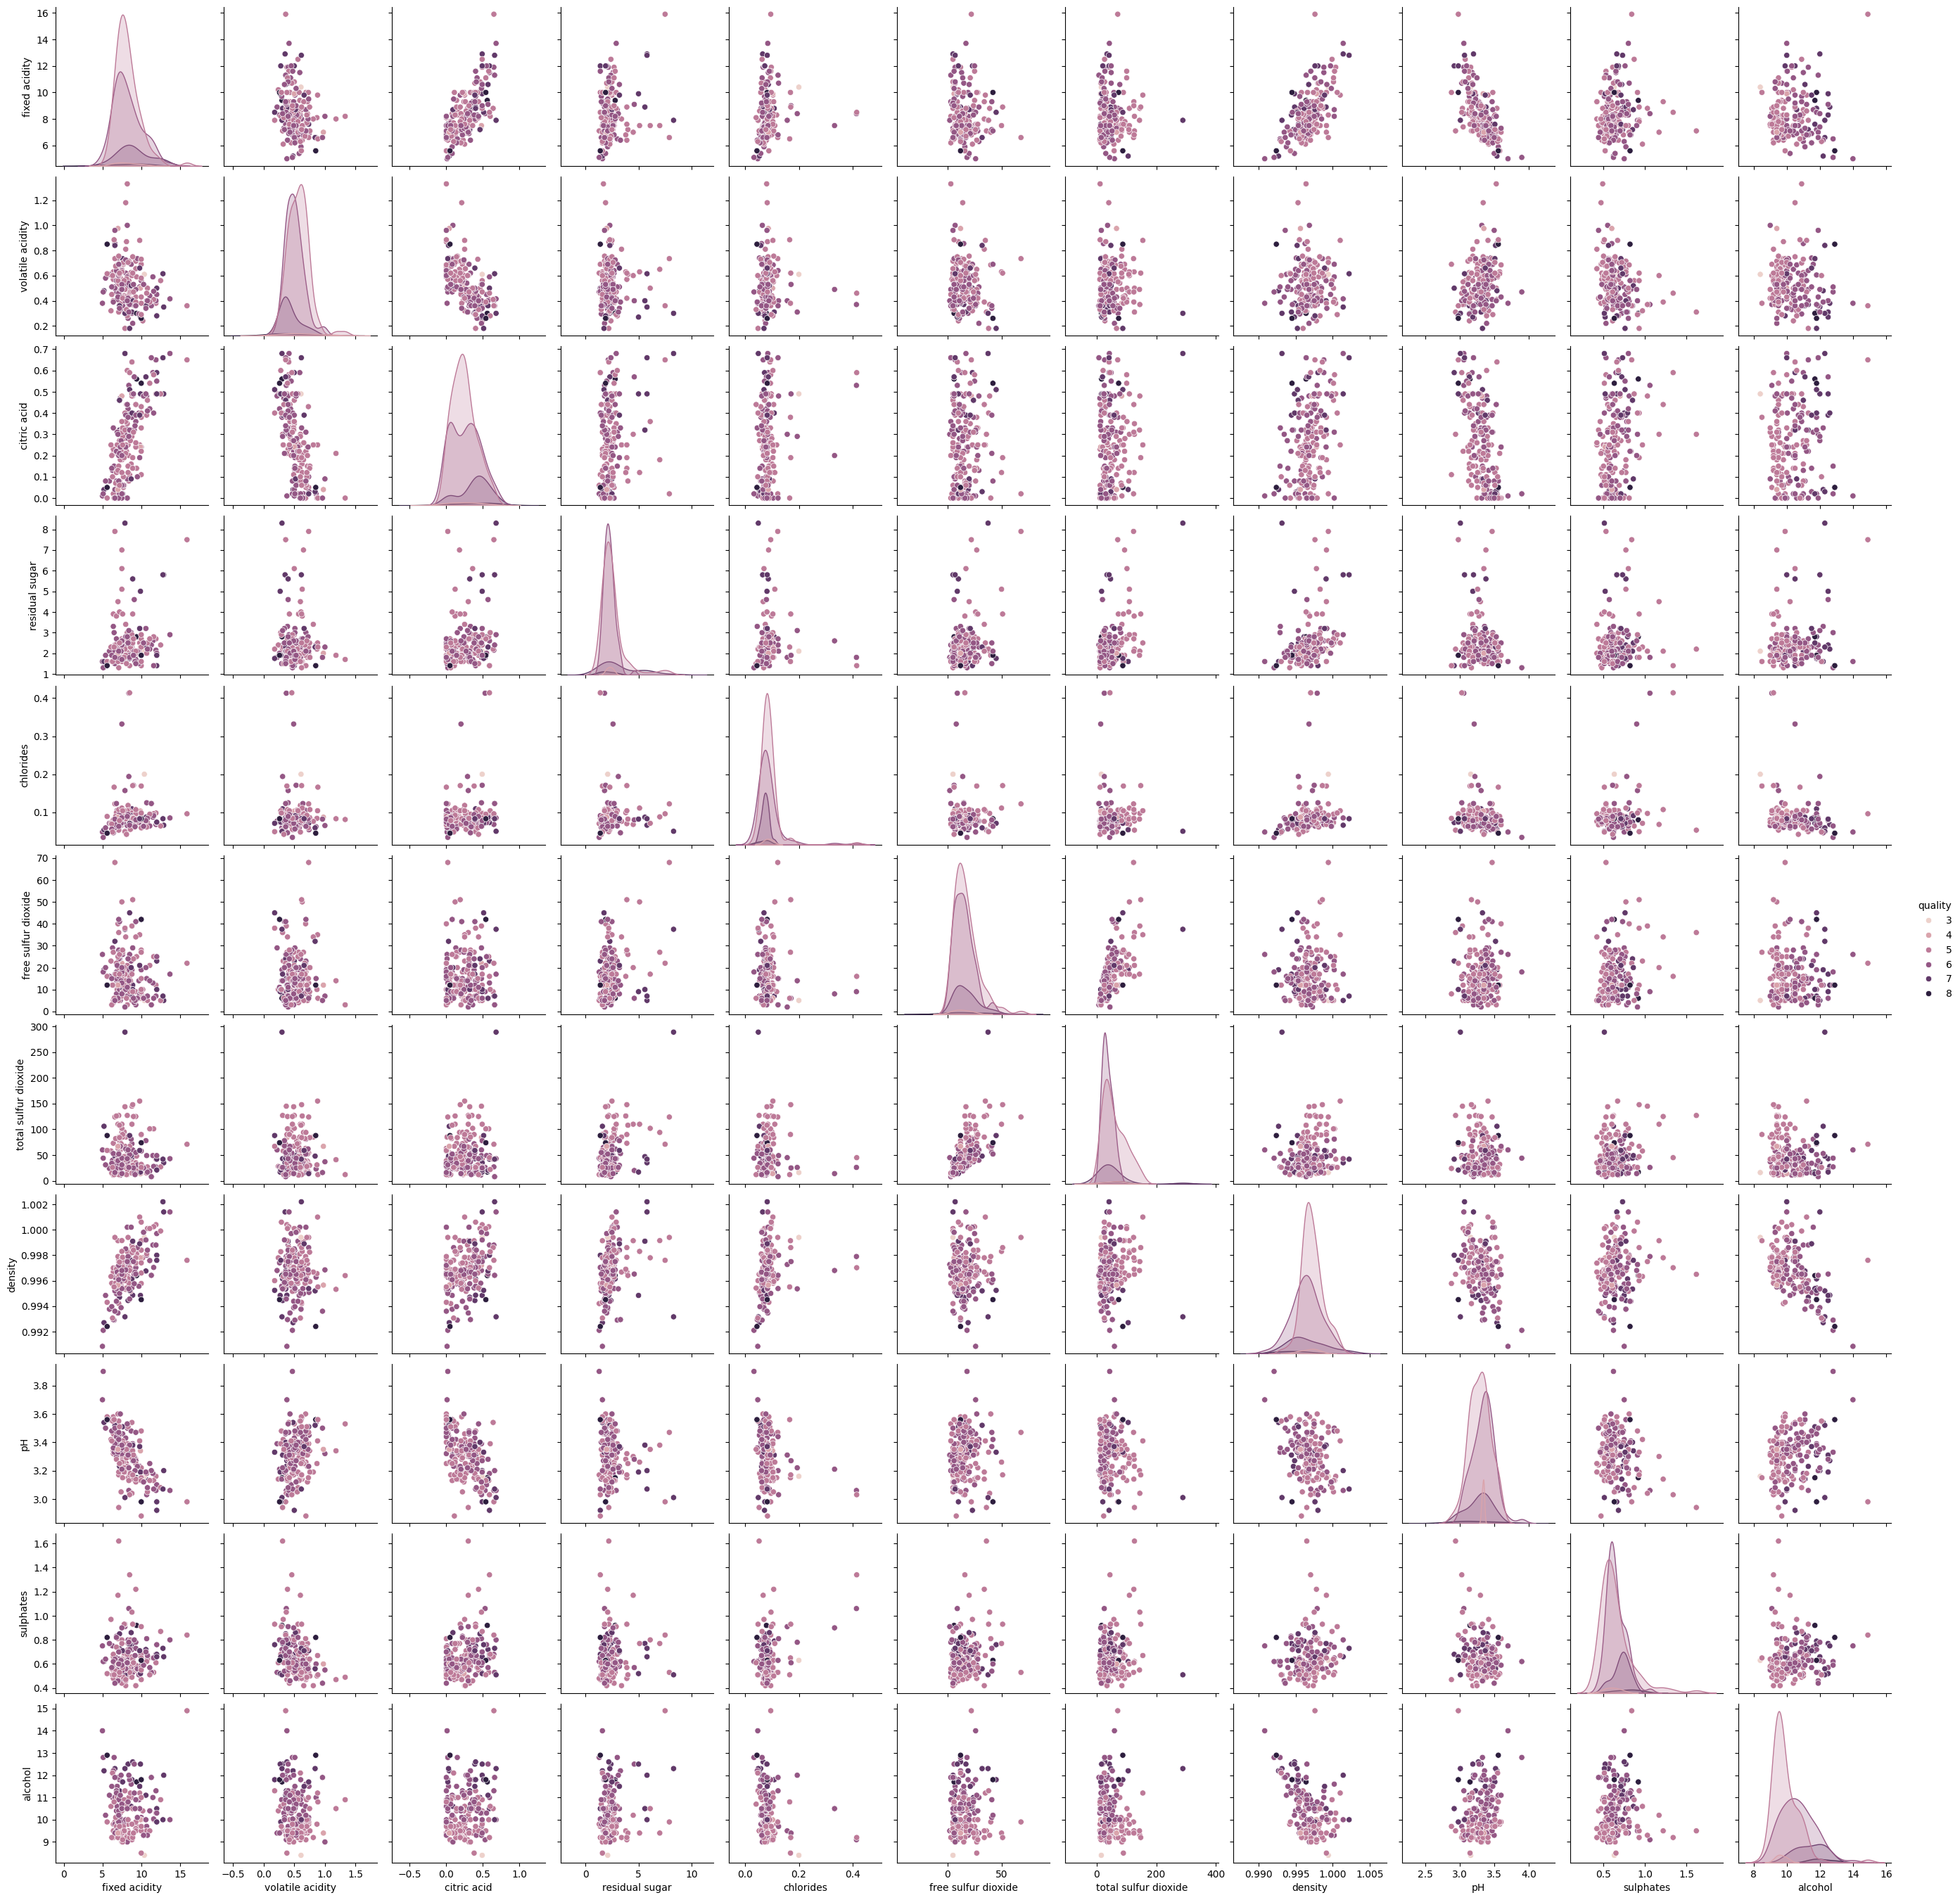

In [ ]:
sns.pairplot(df.sample(200), hue="quality")


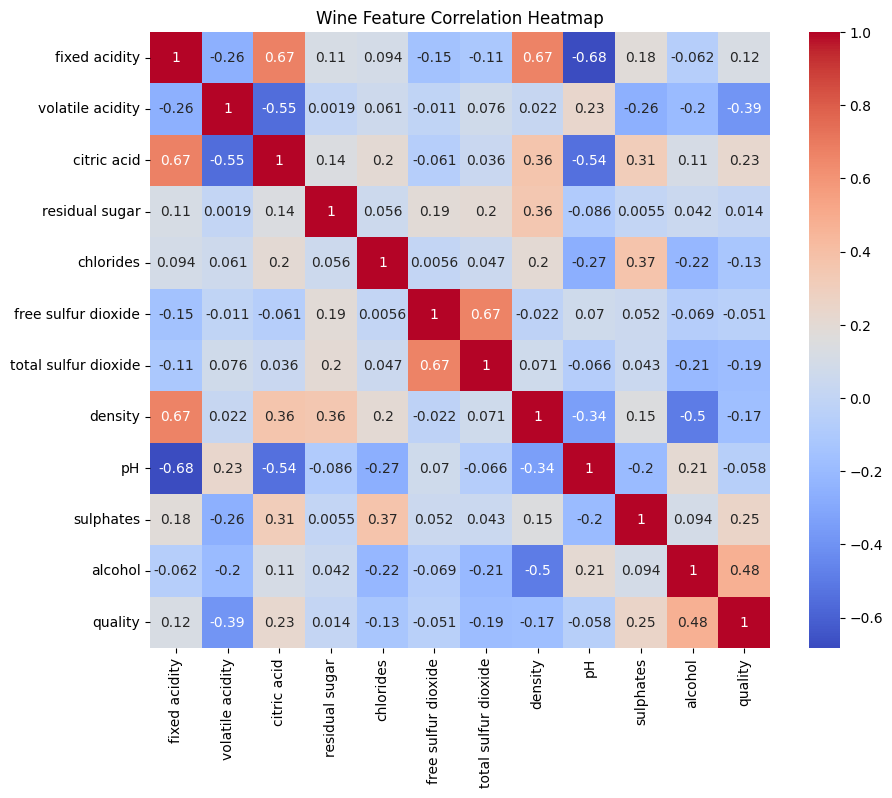

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=True)
plt.title("Wine Feature Correlation Heatmap")
plt.show()


From the correlation heatmap it appears that fixed acidity has a moderately strong negative relationship with pH. Furthermore fixed acidity has a moderately strong positve relationship with citric acid. Additionally free sulfur dioxide has a moderately strong positive relationship with total sulfur diaoxide and density has a moderately strong positive relationship with fixed acidity. As for the relationshps between the features and target variable of wine quality, alcohol appears to have a moderate positive correlation with wine quality and volatile acidity appears to have a negative correlation with wine quality with the other features having quite weak correlations with wine quality. This suggests that the majority of relationships between the wine features and target quality is not strongly linear which suggests that more complex models maybe required to accurately capture the underlying patterns.

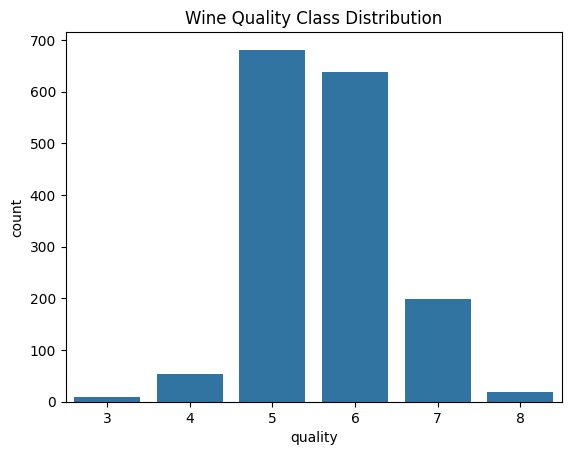

In [ ]:
sns.countplot(x="quality", data=df)
plt.title("Wine Quality Class Distribution")
plt.show()

The distribution of the target variable class (wine quality) is imbalanced as the majority of wine samples are concentrated in quality of 5 and 6, and very few samples belong to the classes 3 and 8.

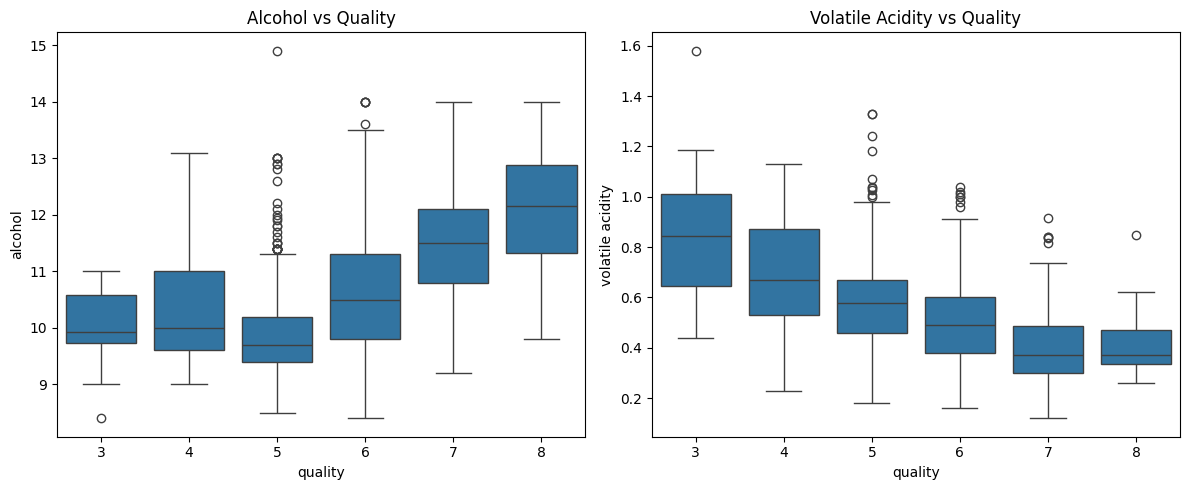

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(ax=axes[0], x="quality", y="alcohol", data=df)
axes[0].set_title("Alcohol vs Quality")

sns.boxplot(ax=axes[1], x="quality", y="volatile acidity", data=df)
axes[1].set_title("Volatile Acidity vs Quality")

plt.tight_layout()
plt.show()

From the correlation heatmap, alcohol and volatile acidity showed the strongest relationships with wine quality. To further examine these relationships, we analyze their distributions across different quality levels using boxplots. The results show that alcohol has a positive relationship with quality, while volatile acidity has a negative relationship with quality.

### Model Training and Evaluation

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #80/20 Split

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### Random Forest Model
We will begin by training a Random Forest Model.
Before tuning hyper parameters I will train and predict using a baseline random forest model.

In [ ]:
random_forest_baseline = RandomForestClassifier(random_state=42)

random_forest_baseline.fit(X_train, y_train)
y_pred_baseline = random_forest_baseline.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred_baseline))
print("Baseline Weighted F1:", f1_score(y_test, y_pred_baseline, average="weighted"))
print(classification_report(y_test, y_pred_baseline))

Baseline Accuracy: 0.659375
Baseline Weighted F1: 0.6437864795480438
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.71      0.74      0.72       130
           6       0.63      0.70      0.66       132
           7       0.64      0.55      0.59        42
           8       0.00      0.00      0.00         5

    accuracy                           0.66       320
   macro avg       0.33      0.33      0.33       320
weighted avg       0.63      0.66      0.64       320



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Now will perfrom grid search to find the best hyperparameters for the Random Forest Model.

In [ ]:
rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 250],
    "max_depth": [None, 5, 10, 20, 25],
    "min_samples_split": [2, 5, 8],
    "min_samples_leaf": [1, 2, 3],
    "class_weight": [None, "balanced"]
}
rf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=rf_cv,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:")
print(grid_rf.best_params_)

print("Best Cross-Validation F1 Score:")
print(grid_rf.best_score_)

Fitting 5 folds for each of 270 candidates, totalling 1350 fits


KeyboardInterrupt: 

In [ ]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Tuned Random Forest Precision:", precision_score(y_test, y_pred_rf, average="weighted", zero_division=0))
print("Tuned Random Forest Recall:", recall_score(y_test, y_pred_rf, average="weighted", zero_division=0))
print("Tuned Random Forest F1:", f1_score(y_test, y_pred_rf, average="weighted", zero_division=0))

print(classification_report(y_test, y_pred_rf, zero_division=0))
print(confusion_matrix(y_test, y_pred_rf))

In [ ]:
confusionMatrix = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7,6))
sns.heatmap(confusionMatrix, annot=True, fmt='d', cmap='viridis',
            xticklabels=[3,4,5,6,7,8],
            yticklabels=[3,4,5,6,7,8])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Value")
plt.title("Random Forest Confusion Matrix (Tuned Model)")
plt.show()


feature_importances = best_rf.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=feat_df)
plt.title("Random Forest Feature Importance")
plt.show()

#### Artificial Neural Network (ANN)

Now I will train and evaluate an Artificial Neural Network model using scikit-learn's MLPClassifier.

First, I will train a baseline ANN model to establish a baseline performance.

In [ ]:
ann_baseline = MLPClassifier(hidden_layer_sizes=(50,), activation="relu", max_iter=1000, random_state=42)

ann_baseline.fit(X_train, y_train)
y_pred_ann_baseline = ann_baseline.predict(X_test)

print("Baseline ANN Accuracy:", accuracy_score(y_test, y_pred_ann_baseline))
print("Baseline ANN Precision:", precision_score(y_test, y_pred_ann_baseline, average="weighted", zero_division=0))
print("Baseline ANN Recall:", recall_score(y_test, y_pred_ann_baseline, average="weighted", zero_division=0))
print("Baseline ANN F1:", f1_score(y_test, y_pred_ann_baseline, average="weighted", zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ann_baseline, zero_division=0))

Now I will perform a grid search to find the best hyperparameters for the ANN model.

In [ ]:
ann = MLPClassifier(max_iter=1000, random_state=42)

param_grid_ann = {
    "hidden_layer_sizes": [(50,), (100,), (50, 50), (100, 50)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01]
}

ann_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_ann = GridSearchCV(
    estimator=ann,
    param_grid=param_grid_ann,
    cv=ann_cv,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

grid_ann.fit(X_train, y_train)

print("Best Parameters:")
print(grid_ann.best_params_)

print("Best Cross-Validation F1 Score:")
print(grid_ann.best_score_)

In [ ]:
best_ann = grid_ann.best_estimator_

y_pred_ann = best_ann.predict(X_test)

print("Tuned ANN Accuracy:", accuracy_score(y_test, y_pred_ann))
print("Tuned ANN Precision:", precision_score(y_test, y_pred_ann, average="weighted", zero_division=0))
print("Tuned ANN Recall:", recall_score(y_test, y_pred_ann, average="weighted", zero_division=0))
print("Tuned ANN F1:", f1_score(y_test, y_pred_ann, average="weighted", zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ann, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ann))

Visualizations for the ANN model:

In [ ]:
cm_ann = confusion_matrix(y_test, y_pred_ann)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('ANN Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
ann_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_ann),
    'Precision': precision_score(y_test, y_pred_ann, average="weighted", zero_division=0),
    'Recall': recall_score(y_test, y_pred_ann, average="weighted", zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_ann, average="weighted", zero_division=0)
}

plt.figure(figsize=(8, 5))
plt.bar(ann_metrics.keys(), ann_metrics.values(), color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.title('ANN Model Metrics')
plt.ylabel('Score')
plt.ylim([0, 1])
plt.show()

In [ ]:
grid_results_ann = pd.DataFrame(grid_ann.cv_results_)

plt.figure(figsize=(10, 6))
plt.plot(range(len(grid_results_ann)), grid_results_ann['mean_test_score'], marker='o', linestyle='-', markersize=4)
plt.xlabel('Parameter Combination')
plt.ylabel('Mean F1-Score (CV)')
plt.title('ANN GridSearch Results - F1 Score Across Parameter Combinations')
plt.grid(True, alpha=0.3)
plt.show()

I now implement a baseline Support Vector Machine (SVM) model using the radial basis function (RBF) kernel. This serves as an initial benchmark to evaluate how well SVM performs on the dataset without any parameter tuning.

In [ ]:
from sklearn.svm import SVC

svm_baseline = SVC(kernel='rbf', random_state=42)

svm_baseline.fit(X_train, y_train)
y_pred_svm_baseline = svm_baseline.predict(X_test)

print("Baseline SVM Accuracy:", accuracy_score(y_test, y_pred_svm_baseline))
print("Baseline SVM Precision:", precision_score(y_test, y_pred_svm_baseline, average="weighted", zero_division=0))
print("Baseline SVM Recall:", recall_score(y_test, y_pred_svm_baseline, average="weighted", zero_division=0))
print("Baseline SVM F1:", f1_score(y_test, y_pred_svm_baseline, average="weighted", zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm_baseline))

Baseline SVM Accuracy: 0.603125
Baseline SVM Precision: 0.5690995065789475
Baseline SVM Recall: 0.603125
Baseline SVM F1: 0.5728911344073244

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.65      0.76      0.70       130
           6       0.56      0.64      0.60       132
           7       0.56      0.21      0.31        42
           8       0.00      0.00      0.00         5

    accuracy                           0.60       320
   macro avg       0.30      0.27      0.27       320
weighted avg       0.57      0.60      0.57       320



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Tuned SVM - I now improve the SVM model by performing hyperparameter tuning using GridSearchCV. The parameters being tuned include the regularization parameter C, the kernel type (linear and RBF), and the gamma parameter. A 5-fold StratifiedKFold cross-validation strategy is used to ensure that class distributions are preserved across folds.

In [ ]:
from sklearn.svm import SVC

svm = SVC(random_state=42)

param_grid_svm = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

svm_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid_svm,
    cv=svm_cv,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train, y_train)

print("Best Parameters:")
print(grid_svm.best_params_)

print("Best Cross-Validation F1 Score:")
print(grid_svm.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters:
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross-Validation F1 Score:
0.6193943052995916


Visualizations for the SVM method

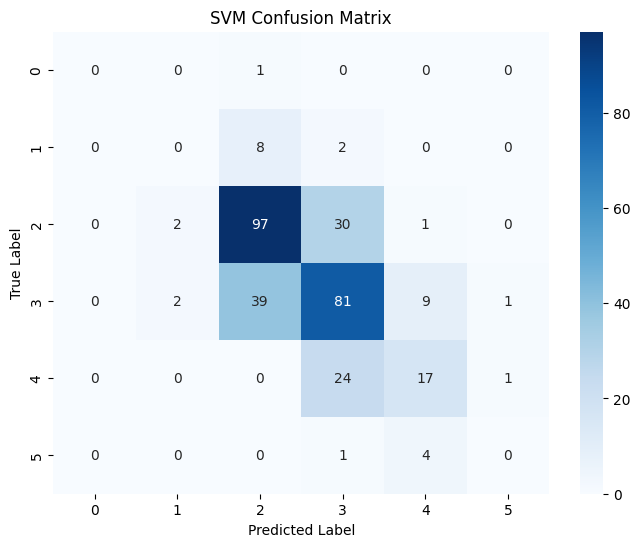

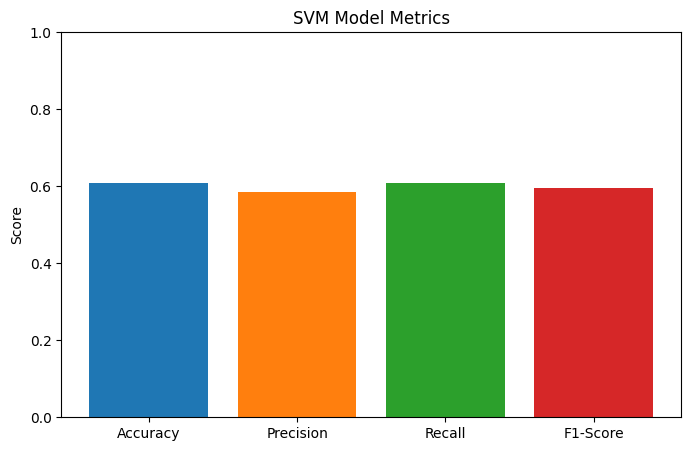

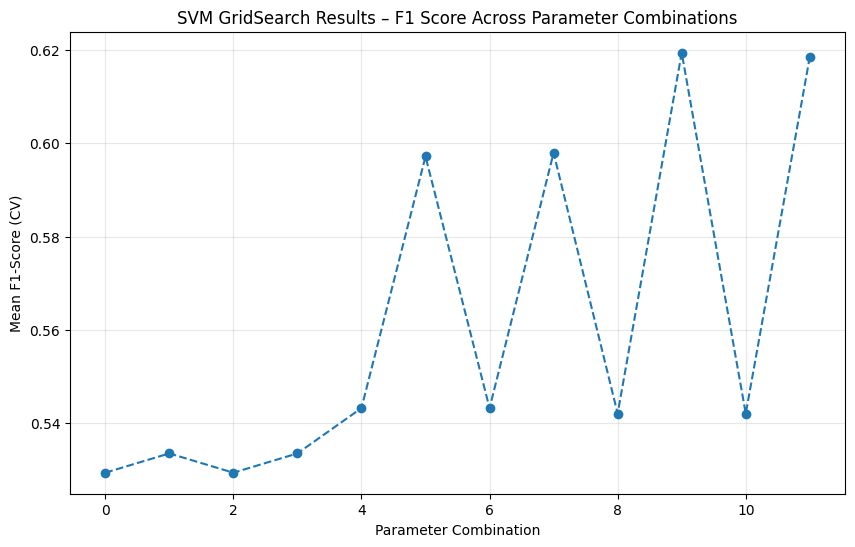

In [ ]:
best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test)

# SVM CONFUSION MATRIX
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('SVM Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


# SVM METRICS BAR CHART
svm_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_svm),
    'Precision': precision_score(y_test, y_pred_svm, average="weighted", zero_division=0),
    'Recall': recall_score(y_test, y_pred_svm, average="weighted", zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_svm, average="weighted", zero_division=0)
}

plt.figure(figsize=(8, 5))
plt.bar(svm_metrics.keys(), svm_metrics.values(),
        color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.title('SVM Model Metrics')
plt.ylabel('Score')
plt.ylim([0, 1])
plt.show()


# SVM GRID SEARCH RESULTS PLOT
grid_results_svm = pd.DataFrame(grid_svm.cv_results_)

plt.figure(figsize=(10, 6))
plt.plot(range(len(grid_results_svm)),
         grid_results_svm['mean_test_score'],
         marker='o', linestyle='--', markersize=6)

plt.xlabel('Parameter Combination')
plt.ylabel('Mean F1-Score (CV)')
plt.title('SVM GridSearch Results – F1 Score Across Parameter Combinations')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
!pwd
!ls

/content
Data  sample_data


In [ ]:
!git clone https://github.com/shangwe-nyota/WineQuality.git

Cloning into 'WineQuality'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 40 (delta 17), reused 31 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 6.42 MiB | 9.76 MiB/s, done.
Resolving deltas: 100% (17/17), done.
